In [3]:
# Cell 1 — setup: imports, seed, device, config

import os, gc, time, pickle
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

# --- reproducibility: same numbers every run ---
SEED = 42
def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

# --- device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))
print("device:", device)

# --- paths / data ---
# Set this to the folder where you unzipped the WESAD dataset

WESAD_DIR = r"PATH\TO\WESAD"   # e.g. r"C:\Users\YourName\any\WESAD"

SUBJECTS  = ["S2","S3","S4","S5","S6","S7","S8","S9","S10",
             "S11","S13","S14","S15","S16","S17"]   # 15 subjects (S1, S12 dropped by WESAD)

# --- labels we keep (from the WESAD readme) ---
LABEL_BASELINE = 1
LABEL_STRESS   = 2
KEEP_LABELS    = {LABEL_BASELINE: 0, LABEL_STRESS: 1}   # remap to 0/1 for training

# --- signal / windowing ---
FS             = 700                      # chest ECG sampling rate (Hz)
WINDOW_SEC     = 10                       # 10 s per window
WINDOW_SAMPLES = FS * WINDOW_SEC          # = 7000 samples
OVERLAP        = 0.5                      # 50% overlap
STEP_SAMPLES   = int(WINDOW_SAMPLES * (1 - OVERLAP))   # = 3500

# --- training knobs (lower these first if you hit out-of-memory) ---
BATCH_SIZE   = 32        # if OOM: try 16, then 8
NUM_EPOCHS   = 30
LR           = 1e-3
USE_AMP      = True      # mixed precision to save VRAM
NUM_WORKERS  = 0         # keep 0 on Windows/Jupyter to avoid loader issues

print("\nwindow:", WINDOW_SAMPLES, "samples |", "step:", STEP_SAMPLES, "samples")
print("subjects:", len(SUBJECTS))

torch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM (GB): 4.29
device: cuda

window: 7000 samples | step: 3500 samples
subjects: 15


In [4]:
# Cell 2 — load ONE subject and look at it (S2)

subj = "S2"
pkl_path = os.path.join(WESAD_DIR, subj, f"{subj}.pkl")
print("loading:", pkl_path)

# WESAD pkls were saved in Python 2 -> need latin1 to unpickle in Python 3
with open(pkl_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

# keys in these pkls can be bytes (b'signal') or str ('signal') -> handle both
def get_key(d, name):
    if name in d:
        return d[name]
    if name.encode() in d:
        return d[name.encode()]
    raise KeyError(f"'{name}' not found. keys = {list(d.keys())}")

signal = get_key(data, "signal")
chest  = get_key(signal, "chest")
ecg    = np.asarray(get_key(chest, "ECG")).astype(np.float32)        # shape (N, 1)
labels = np.asarray(get_key(data, "label")).astype(np.int64).ravel() # shape (N,)

print("\nECG shape:  ", ecg.shape)
print("label shape:", labels.shape)
print("same length:", ecg.shape[0] == labels.shape[0])

# what do the ECG values actually look like? (tells us raw counts vs mV)
print("\nECG min/max/mean/std: %.4f / %.4f / %.4f / %.4f" %
      (ecg.min(), ecg.max(), ecg.mean(), ecg.std()))

# which labels are present and how big each is (700 Hz samples)
uniq, counts = np.unique(labels, return_counts=True)
print("\nlabel : count      (seconds)")
for u, c in zip(uniq, counts):
    print(f"  {int(u)} : {int(c):>9d}  ({c/FS:7.1f} s)")

# free the ~800 MB before moving on
del data, signal, chest, ecg, labels
gc.collect()
print("\nfreed S2 from memory.")

loading: C:\Users\abdal\Downloads\WESAD\S2\S2.pkl

ECG shape:   (4255300, 1)
label shape: (4255300,)
same length: True

ECG min/max/mean/std: -1.4995 / 1.4993 / 0.0012 / 0.1541

label : count      (seconds)
  0 :   2142701  ( 3061.0 s)
  1 :    800800  ( 1144.0 s)
  2 :    430500  (  615.0 s)
  3 :    253400  (  362.0 s)
  4 :    537599  (  768.0 s)
  6 :     45500  (   65.0 s)
  7 :     44800  (   64.0 s)

freed S2 from memory.


In [5]:
# Cell 3 — preprocess ALL subjects (one at a time) into windows

EPS = 1e-8

# same key helper as Cell 2 (redefined so this cell stands on its own)
def get_key(d, name):
    if name in d: return d[name]
    if name.encode() in d: return d[name.encode()]
    raise KeyError(f"'{name}' not found. keys = {list(d.keys())}")

def contiguous_segments(lab):
    # yield (start, end, label_value) for each maximal run of one label
    change = np.where(np.diff(lab) != 0)[0] + 1
    bounds = np.concatenate(([0], change, [len(lab)]))
    for i in range(len(bounds) - 1):
        s, e = int(bounds[i]), int(bounds[i + 1])
        yield s, e, int(lab[s])

X_list, y_list, g_list = [], [], []
per_subj = []

t0 = time.time()
for si, subj in enumerate(SUBJECTS):
    pkl_path = os.path.join(WESAD_DIR, subj, f"{subj}.pkl")
    with open(pkl_path, "rb") as f:
        data = pickle.load(f, encoding="latin1")

    # copy ECG + labels out, then drop the big dict so memory is freed each loop
    sig = get_key(data, "signal")
    ecg = np.array(get_key(get_key(sig, "chest"), "ECG"), dtype=np.float32).ravel()
    lab = np.array(get_key(data, "label"), dtype=np.int64).ravel()
    del data, sig
    gc.collect()

    # per-subject z-score: removes that surgeon's amplitude offset/gain
    ecg = (ecg - ecg.mean()) / (ecg.std() + EPS)

    n_base, n_str = 0, 0
    for s, e, lv in contiguous_segments(lab):
        if lv not in KEEP_LABELS:           # keep only baseline(1) and stress(2)
            continue
        cls = KEEP_LABELS[lv]
        pos = s
        while pos + WINDOW_SAMPLES <= e:    # window stays inside one label run
            X_list.append(ecg[pos:pos + WINDOW_SAMPLES].copy())
            y_list.append(cls)
            g_list.append(si)
            if cls == 0: n_base += 1
            else:        n_str += 1
            pos += STEP_SAMPLES

    per_subj.append((subj, n_base, n_str))
    print(f"{subj:>4}: baseline={n_base:4d}  stress={n_str:4d}  (running total={len(y_list)})")

    del ecg, lab
    gc.collect()

# stack into arrays
X = np.stack(X_list).astype(np.float32)     # (N, 7000)
y = np.array(y_list, dtype=np.int64)        # (N,)
groups = np.array(g_list, dtype=np.int64)   # (N,) -> index into SUBJECTS
del X_list, y_list, g_list
gc.collect()

print("\n--- done in %.1f s ---" % (time.time() - t0))
print("X:", X.shape, X.dtype, " y:", y.shape, " groups:", groups.shape)
vals, cnts = np.unique(y, return_counts=True)
print("class counts:", dict(zip(vals.tolist(), cnts.tolist())), " (0=baseline, 1=stress)")
print("imbalance baseline:stress = %.2f : 1" % (cnts[0] / cnts[1]))

# save so we never touch the 800 MB pkls again (reload instantly after a kernel restart)
os.makedirs("processed", exist_ok=True)
np.save("processed/X.npy", X); np.save("processed/y.npy", y); np.save("processed/groups.npy", groups)
print("saved -> processed/X.npy, y.npy, groups.npy")

  S2: baseline= 227  stress= 122  (running total=349)
  S3: baseline= 227  stress= 127  (running total=703)
  S4: baseline= 230  stress= 126  (running total=1059)
  S5: baseline= 238  stress= 128  (running total=1425)
  S6: baseline= 235  stress= 129  (running total=1789)
  S7: baseline= 236  stress= 127  (running total=2152)
  S8: baseline= 232  stress= 133  (running total=2517)
  S9: baseline= 235  stress= 128  (running total=2880)
 S10: baseline= 235  stress= 144  (running total=3259)
 S11: baseline= 235  stress= 135  (running total=3629)
 S13: baseline= 235  stress= 131  (running total=3995)
 S14: baseline= 235  stress= 134  (running total=4364)
 S15: baseline= 234  stress= 136  (running total=4734)
 S16: baseline= 235  stress= 133  (running total=5102)
 S17: baseline= 235  stress= 143  (running total=5480)

--- done in 62.8 s ---
X: (5480, 7000) float32  y: (5480,)  groups: (5480,)
class counts: {0: 3504, 1: 1976}  (0=baseline, 1=stress)
imbalance baseline:stress = 1.77 : 1
saved 

In [6]:
# Cell 4 — subject-wise train/val/test split (no subject in two sets)

# reload from disk so this cell works even after a kernel restart
X      = np.load("processed/X.npy")
y      = np.load("processed/y.npy")
groups = np.load("processed/groups.npy")

# split by SUBJECT, not by window. 10 train / 2 val / 3 test.
# picked so val and test each contain both classes and a female subject where possible.
test_subj  = ["S4", "S9", "S15"]
val_subj   = ["S6", "S13"]
train_subj = [s for s in SUBJECTS if s not in test_subj + val_subj]

name_to_idx = {s: i for i, s in enumerate(SUBJECTS)}
test_ids  = [name_to_idx[s] for s in test_subj]
val_ids   = [name_to_idx[s] for s in val_subj]
train_ids = [name_to_idx[s] for s in train_subj]

train_mask = np.isin(groups, train_ids)
val_mask   = np.isin(groups, val_ids)
test_mask  = np.isin(groups, test_ids)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# sanity: the three sets must not overlap and must cover everything
assert train_mask.sum() + val_mask.sum() + test_mask.sum() == len(y)
assert not (set(train_ids) & set(val_ids) & set(test_ids))

def show(split, subs, yy):
    n0 = int((yy == 0).sum()); n1 = int((yy == 1).sum())
    print(f"{split:<6} {str(subs):<34} n={len(yy):4d}  baseline={n0:4d}  stress={n1:4d}")

print("split  subjects                           windows  per-class")
show("train", train_subj, y_train)
show("val",   val_subj,   y_val)
show("test",  test_subj,  y_test)

# class weights for the loss, computed on TRAIN ONLY (never peek at val/test)
counts = np.array([(y_train == 0).sum(), (y_train == 1).sum()], dtype=np.float32)
class_weights = counts.sum() / (2.0 * counts)     # inverse-frequency, normalized
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("\nclass weights (baseline, stress):", class_weights.tolist())

split  subjects                           windows  per-class
train  ['S2', 'S3', 'S5', 'S7', 'S8', 'S10', 'S11', 'S14', 'S16', 'S17'] n=3661  baseline=2335  stress=1326
val    ['S6', 'S13']                      n= 730  baseline= 470  stress= 260
test   ['S4', 'S9', 'S15']                n=1089  baseline= 699  stress= 390

class weights (baseline, stress): [0.7839400172233582, 1.3804675340652466]


In [7]:
# Cell 5 — Dataset + DataLoader

class ECGWindows(Dataset):
    def __init__(self, X, y):
        # (N, 7000) -> (N, 1, 7000): Conv1d wants a channel axis
        self.X = torch.from_numpy(X).float().unsqueeze(1)
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_ds = ECGWindows(X_train, y_train)
val_ds   = ECGWindows(X_val,   y_val)
test_ds  = ECGWindows(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("datasets (train/val/test):", len(train_ds), len(val_ds), len(test_ds))
print("batches  (train/val/test):", len(train_loader), len(val_loader), len(test_loader))

# pull ONE batch to confirm the exact tensor shape going into the model
xb, yb = next(iter(train_loader))
print("\none batch:")
print("  x:", tuple(xb.shape), xb.dtype)   # expect (32, 1, 7000) float32
print("  y:", tuple(yb.shape), yb.dtype)   # expect (32,) int64
print("  classes in this batch:", torch.unique(yb).tolist())

datasets (train/val/test): 3661 730 1089
batches  (train/val/test): 115 23 35

one batch:
  x: (32, 1, 7000) torch.float32
  y: (32,) torch.int64
  classes in this batch: [0, 1]


In [8]:
# Cell 6 — Model A: plain 1D CNN (ResNet-style, size-17 kernels, residual shortcuts)

class ResidualBlock1D(nn.Module):
    # two conv layers + a shortcut. attn stays None for Model A (CBAM plugs in here for Model B)
    def __init__(self, in_c, out_c, k=17, stride=1, attn=None):
        super().__init__()
        pad = k // 2
        self.conv1 = nn.Conv1d(in_c, out_c, k, stride=stride, padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_c)
        self.conv2 = nn.Conv1d(out_c, out_c, k, stride=1, padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_c)
        self.attn  = attn
        # shortcut has to match shape when channels grow or we downsample
        if stride != 1 or in_c != out_c:
            self.short = nn.Sequential(
                nn.Conv1d(in_c, out_c, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_c),
            )
        else:
            self.short = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.attn is not None:
            out = self.attn(out)          # CBAM refines features before the add (Model B only)
        out = out + self.short(x)         # residual shortcut
        return F.relu(out)


class ECGNet(nn.Module):
    def __init__(self, n_classes=2, base=32, k=17, p_drop=0.3, attn_factory=None):
        super().__init__()
        def make_attn(c):
            return attn_factory(c) if attn_factory is not None else None
        # stem: first big-kernel conv + downsample so the 7000-long signal shrinks early
        self.stem = nn.Sequential(
            nn.Conv1d(1, base, k, stride=2, padding=k // 2, bias=False),
            nn.BatchNorm1d(base),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
        )
        self.layer1 = ResidualBlock1D(base,     base,     k, stride=1, attn=make_attn(base))
        self.layer2 = ResidualBlock1D(base,     base * 2, k, stride=2, attn=make_attn(base * 2))
        self.layer3 = ResidualBlock1D(base * 2, base * 4, k, stride=2, attn=make_attn(base * 4))
        self.pool = nn.AdaptiveAvgPool1d(1)   # length-independent: one value per channel
        self.drop = nn.Dropout(p_drop)
        self.fc   = nn.Linear(base * 4, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x).squeeze(-1)          # (B, base*4)
        x = self.drop(x)
        return self.fc(x)                     # (B, 2) logits


set_seed(SEED)   # reproducible weight init
model_A = ECGNet(n_classes=2, base=32, k=17, p_drop=0.3, attn_factory=None).to(device)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print("Model A (plain 1D CNN) trainable params:", f"{count_params(model_A):,}")

# one forward pass on a dummy batch to confirm the output is (32, 2) logits
model_A.eval()
with torch.no_grad():
    dummy = torch.randn(BATCH_SIZE, 1, WINDOW_SAMPLES, device=device)
    out = model_A(dummy)
print("dummy in:", tuple(dummy.shape), "-> out:", tuple(out.shape))

del dummy, out
gc.collect(); torch.cuda.empty_cache()
print("Model A built OK.")

Model A (plain 1D CNN) trainable params: 569,442
dummy in: (32, 1, 7000) -> out: (32, 2)
Model A built OK.


In [9]:
# Cell 7 — Model B: 1D CNN + CBAM (Woo et al. attention, adapted to 1D)

class CBAM1d(nn.Module):
    # channel attention (which feature maps matter) then spatial attention (which time positions matter)
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        hidden = max(channels // reduction, 1)
        # channel attention: a shared MLP applied to avg- and max-pooled descriptors
        self.mlp = nn.Sequential(
            nn.Conv1d(channels, hidden, 1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden, channels, 1, bias=True),
        )
        # spatial attention: conv over [avg, max] taken across the channel axis
        self.spatial = nn.Conv1d(2, 1, spatial_kernel, padding=spatial_kernel // 2, bias=False)

    def forward(self, x):
        # channel attention -> reweight channels
        avg = F.adaptive_avg_pool1d(x, 1)            # (B, C, 1)
        mx  = F.adaptive_max_pool1d(x, 1)            # (B, C, 1)
        ca  = torch.sigmoid(self.mlp(avg) + self.mlp(mx))
        x   = x * ca
        # spatial attention -> reweight time positions
        avg_s = x.mean(dim=1, keepdim=True)          # (B, 1, L)
        mx_s  = x.max(dim=1, keepdim=True)[0]        # (B, 1, L)
        sa    = torch.sigmoid(self.spatial(torch.cat([avg_s, mx_s], dim=1)))
        return x * sa


set_seed(SEED)   # same init seed as Model A
model_B = ECGNet(n_classes=2, base=32, k=17, p_drop=0.3, attn_factory=CBAM1d).to(device)

print("Model B (1D CNN + CBAM) trainable params:", f"{count_params(model_B):,}")
print("Model A params:", f"{count_params(model_A):,}")
print("CBAM overhead :", f"{count_params(model_B) - count_params(model_A):,}")

# confirm B still outputs (32, 2)
model_B.eval()
with torch.no_grad():
    dummy = torch.randn(BATCH_SIZE, 1, WINDOW_SAMPLES, device=device)
    out = model_B(dummy)
print("dummy in:", tuple(dummy.shape), "-> out:", tuple(out.shape))

del dummy, out
gc.collect(); torch.cuda.empty_cache()
print("Model B built OK.")

Model B (1D CNN + CBAM) trainable params: 572,410
Model A params: 569,442
CBAM overhead : 2,968
dummy in: (32, 1, 7000) -> out: (32, 2)
Model B built OK.


In [10]:
# Cell 8b — stabilized training (lower LR + scheduler + weight decay + augmentation), re-train Model A

import copy
from sklearn.metrics import balanced_accuracy_score

criterion = nn.CrossEntropyLoss(weight=class_weights)

def augment_batch(xb):
    # light ECG augmentation, train only -> makes memorizing harder, helps noise robustness
    b = xb.size(0)
    scale = 0.8 + 0.4 * torch.rand(b, 1, 1, device=xb.device)   # amplitude +/-20%
    xb = xb * scale
    xb = xb + 0.05 * torch.randn_like(xb)                       # small gaussian noise
    shift = int(torch.randint(-140, 141, (1,)).item())          # +/-0.2 s time shift
    xb = torch.roll(xb, shifts=shift, dims=2)
    return xb

def run_epoch(model, loader, optimizer=None, scaler=None, augment=False):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, total_n = 0.0, 0
    all_true, all_pred = [], []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        if augment:
            xb = augment_batch(xb)
        with torch.set_grad_enabled(train):
            with torch.amp.autocast(device_type=device.type, enabled=(USE_AMP and device.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
        total_loss += loss.item() * xb.size(0); total_n += xb.size(0)
        all_true.append(yb.cpu()); all_pred.append(logits.argmax(1).cpu())
    yt = torch.cat(all_true).numpy(); yp = torch.cat(all_pred).numpy()
    return total_loss / total_n, (yt == yp).mean(), balanced_accuracy_score(yt, yp)

def train_model(model, name, epochs=40, lr=3e-4, wd=1e-3, patience=10):
    scaler    = torch.amp.GradScaler("cuda", enabled=(USE_AMP and device.type == "cuda"))
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "train_bal": [], "val_bal": []}
    best_bal, best_state, bad = -1.0, copy.deepcopy(model.state_dict()), 0

    t0 = time.time()
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc, tr_bal = run_epoch(model, train_loader, optimizer, scaler, augment=True)
        va_loss, va_acc, va_bal = run_epoch(model, val_loader)
        scheduler.step(va_bal)
        for k, v in zip(history, [tr_loss, va_loss, tr_acc, va_acc, tr_bal, va_bal]):
            history[k].append(v)

        flag = ""
        if va_bal > best_bal:
            best_bal, best_state, bad = va_bal, copy.deepcopy(model.state_dict()), 0
            flag = "  <- best"
        else:
            bad += 1

        lr_now = optimizer.param_groups[0]["lr"]
        print(f"[{name}] ep {ep:2d}/{epochs}  lr={lr_now:.1e}  "
              f"train: loss={tr_loss:.3f} bal={tr_bal:.3f}  |  "
              f"val: loss={va_loss:.3f} acc={va_acc:.3f} bal={va_bal:.3f}{flag}")

        if bad >= patience:
            print(f"[{name}] early stop at epoch {ep}")
            break

    model.load_state_dict(best_state)
    torch.save(best_state, f"processed/model_{name}.pt")
    print(f"[{name}] done in {time.time()-t0:.1f}s  best val balanced-acc={best_bal:.3f}")
    return history

# rebuild Model A FRESH (more dropout), train under the new regime
set_seed(SEED)
model_A = ECGNet(n_classes=2, base=32, k=17, p_drop=0.5, attn_factory=None).to(device)
hist_A = train_model(model_A, "A")

[A] ep  1/40  lr=3.0e-04  train: loss=0.193 bal=0.933  |  val: loss=0.321 acc=0.860 bal=0.818  <- best
[A] ep  2/40  lr=3.0e-04  train: loss=0.058 bal=0.986  |  val: loss=0.650 acc=0.660 bal=0.722
[A] ep  3/40  lr=3.0e-04  train: loss=0.044 bal=0.988  |  val: loss=0.704 acc=0.693 bal=0.761
[A] ep  4/40  lr=3.0e-04  train: loss=0.034 bal=0.991  |  val: loss=0.503 acc=0.748 bal=0.646
[A] ep  5/40  lr=1.5e-04  train: loss=0.024 bal=0.993  |  val: loss=1.717 acc=0.667 bal=0.741
[A] ep  6/40  lr=1.5e-04  train: loss=0.014 bal=0.997  |  val: loss=0.579 acc=0.719 bal=0.743
[A] ep  7/40  lr=1.5e-04  train: loss=0.010 bal=0.997  |  val: loss=0.646 acc=0.707 bal=0.724
[A] ep  8/40  lr=1.5e-04  train: loss=0.019 bal=0.994  |  val: loss=0.406 acc=0.810 bal=0.803
[A] ep  9/40  lr=7.5e-05  train: loss=0.006 bal=0.999  |  val: loss=0.967 acc=0.632 bal=0.679
[A] ep 10/40  lr=7.5e-05  train: loss=0.005 bal=0.999  |  val: loss=0.941 acc=0.655 bal=0.710
[A] ep 11/40  lr=7.5e-05  train: loss=0.006 bal=0.9

In [11]:
# Cell 9 — Leave-One-Subject-Out (LOSO) evaluation, run for Model A

import copy
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report

def make_loader(mask, shuffle):
    ds = ECGWindows(X[mask], y[mask])
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=True)

def train_one_fold(test_i, attn_factory, epochs=40, lr=3e-4, wd=1e-3, patience=10):
    global criterion
    val_i = (test_i + 1) % len(SUBJECTS)              # 1 inner-val subject, only for early stopping
    test_mask  = np.isin(groups, [test_i])
    val_mask   = np.isin(groups, [val_i])
    train_mask = ~(test_mask | val_mask)              # the other 13 subjects

    tr_loader = make_loader(train_mask, True)
    va_loader = make_loader(val_mask,   False)
    te_loader = make_loader(test_mask,  False)

    # per-fold class weights: the training set changes every fold, so recompute (train only)
    ytr = y[train_mask]
    cnt = np.array([(ytr == 0).sum(), (ytr == 1).sum()], dtype=np.float32)
    cw  = torch.tensor(cnt.sum() / (2.0 * cnt), dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=cw)        # run_epoch reads this global

    set_seed(SEED)                                    # identical init each fold -> only the data differs
    model  = ECGNet(n_classes=2, base=32, k=17, p_drop=0.5, attn_factory=attn_factory).to(device)
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=3)
    scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and device.type == "cuda"))

    history = {"train_bal": [], "val_bal": [], "train_loss": [], "val_loss": []}
    best_bal, best_state, bad, ep_run = -1.0, copy.deepcopy(model.state_dict()), 0, 0
    for ep in range(1, epochs + 1):
        tr_loss, _, tr_bal = run_epoch(model, tr_loader, opt, scaler, augment=True)
        va_loss, _, va_bal = run_epoch(model, va_loader)
        sched.step(va_bal)
        history["train_bal"].append(tr_bal); history["val_bal"].append(va_bal)
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        ep_run = ep
        if va_bal > best_bal:
            best_bal, best_state, bad = va_bal, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)                 # keep best inner-val epoch

    # predict the held-out TEST subject (never trained on, never used for stopping)
    model.eval()
    yt, yp = [], []
    with torch.no_grad():
        for xb, yb in te_loader:
            xb = xb.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, enabled=(USE_AMP and device.type == "cuda")):
                logits = model(xb)
            yt.append(yb.numpy()); yp.append(logits.argmax(1).cpu().numpy())
    yt, yp = np.concatenate(yt), np.concatenate(yp)

    del model, opt, sched, scaler, tr_loader, va_loader, te_loader
    gc.collect(); torch.cuda.empty_cache()
    return balanced_accuracy_score(yt, yp), (yt == yp).mean(), yt, yp, best_bal, ep_run, history


def run_loso(attn_factory, tag):
    print(f"LOSO for Model {tag} — 15 folds\n")
    bals, accs, trues, preds, hists = [], [], [], [], []
    t0 = time.time()
    for ti, subj in enumerate(SUBJECTS):
        tb, ta, yt, yp, bv, ep, hist = train_one_fold(ti, attn_factory)
        bals.append(tb); accs.append(ta); trues.append(yt); preds.append(yp); hists.append(hist)
        print(f"  fold {ti+1:2d}/15  test={subj:>4}  n={len(yt):4d}  epochs={ep:2d}  "
              f"test_bal={tb:.3f}  test_acc={ta:.3f}")
    bals, accs = np.array(bals), np.array(accs)
    true_all, pred_all = np.concatenate(trues), np.concatenate(preds)

    print(f"\n=== Model {tag} LOSO summary ===")
    print("balanced acc: mean=%.3f  std=%.3f  (min=%.3f, max=%.3f)" %
          (bals.mean(), bals.std(), bals.min(), bals.max()))
    print("plain acc   : mean=%.3f  std=%.3f" % (accs.mean(), accs.std()))
    print("total time  : %.1f s\n" % (time.time() - t0))
    print("pooled confusion matrix (rows=true, cols=pred) [0=baseline, 1=stress]:")
    print(confusion_matrix(true_all, pred_all, labels=[0, 1]))
    print("\npooled per-class report:")
    print(classification_report(true_all, pred_all, labels=[0, 1],
                                target_names=["baseline", "stress"], digits=3))

    rep = int(np.argmin(np.abs(bals - bals.mean())))     # fold nearest the mean -> use for Fig 2 curves
    np.save(f"processed/loso_{tag}_true.npy", true_all)
    np.save(f"processed/loso_{tag}_pred.npy", pred_all)
    np.save(f"processed/loso_{tag}_bals.npy", bals)
    np.save(f"processed/loso_{tag}_rep_history.npy", hists[rep], allow_pickle=True)
    print(f"saved Model {tag}. representative fold for curves: {SUBJECTS[rep]} (test_bal={bals[rep]:.3f})")
    return {"bals": bals, "accs": accs, "true": true_all, "pred": pred_all, "rep_hist": hists[rep]}


res_A = run_loso(attn_factory=None, tag="A")

LOSO for Model A — 15 folds

  fold  1/15  test=  S2  n= 349  epochs=15  test_bal=0.500  test_acc=0.350
  fold  2/15  test=  S3  n= 354  epochs=19  test_bal=0.512  test_acc=0.381
  fold  3/15  test=  S4  n= 356  epochs=12  test_bal=0.909  test_acc=0.935
  fold  4/15  test=  S5  n= 366  epochs=14  test_bal=0.875  test_acc=0.913
  fold  5/15  test=  S6  n= 364  epochs=18  test_bal=0.937  test_acc=0.940
  fold  6/15  test=  S7  n= 363  epochs=14  test_bal=0.979  test_acc=0.972
  fold  7/15  test=  S8  n= 365  epochs=14  test_bal=0.998  test_acc=0.997
  fold  8/15  test=  S9  n= 363  epochs=27  test_bal=0.880  test_acc=0.882
  fold  9/15  test= S10  n= 379  epochs=21  test_bal=0.515  test_acc=0.398
  fold 10/15  test= S11  n= 370  epochs=13  test_bal=0.996  test_acc=0.995
  fold 11/15  test= S13  n= 366  epochs=15  test_bal=0.962  test_acc=0.951
  fold 12/15  test= S14  n= 369  epochs=17  test_bal=0.981  test_acc=0.986
  fold 13/15  test= S15  n= 370  epochs=11  test_bal=0.509  test_acc=0.

In [12]:
# Cell 10 — same LOSO, now for Model B (1D CNN + CBAM)

res_B = run_loso(attn_factory=CBAM1d, tag="B")

LOSO for Model B — 15 folds

  fold  1/15  test=  S2  n= 349  epochs=12  test_bal=0.500  test_acc=0.350
  fold  2/15  test=  S3  n= 354  epochs=13  test_bal=0.700  test_acc=0.720
  fold  3/15  test=  S4  n= 356  epochs=12  test_bal=0.631  test_acc=0.739
  fold  4/15  test=  S5  n= 366  epochs=15  test_bal=0.500  test_acc=0.650
  fold  5/15  test=  S6  n= 364  epochs=28  test_bal=0.614  test_acc=0.698
  fold  6/15  test=  S7  n= 363  epochs=24  test_bal=0.748  test_acc=0.672
  fold  7/15  test=  S8  n= 365  epochs=20  test_bal=0.987  test_acc=0.984
  fold  8/15  test=  S9  n= 363  epochs=15  test_bal=0.574  test_acc=0.680
  fold  9/15  test= S10  n= 379  epochs=11  test_bal=0.577  test_acc=0.478
  fold 10/15  test= S11  n= 370  epochs=18  test_bal=0.996  test_acc=0.995
  fold 11/15  test= S13  n= 366  epochs=13  test_bal=0.526  test_acc=0.391
  fold 12/15  test= S14  n= 369  epochs=27  test_bal=1.000  test_acc=1.000
  fold 13/15  test= S15  n= 370  epochs=11  test_bal=0.605  test_acc=0.

In [13]:
# Cell 11 — A vs B comparison table (per-class, both models) + key deltas

from sklearn.metrics import precision_recall_fscore_support, balanced_accuracy_score

def per_class(true_all, pred_all):
    p, r, f, s = precision_recall_fscore_support(true_all, pred_all, labels=[0, 1], zero_division=0)
    return p, r, f, s

pA, rA, fA, sup = per_class(res_A["true"], res_A["pred"])
pB, rB, fB, _   = per_class(res_B["true"], res_B["pred"])

balA, balB = res_A["bals"], res_B["bals"]

print("LOSO comparison — Model A (plain 1D CNN) vs Model B (1D CNN + CBAM)")
print("=" * 68)
print("Subject-independent, 15 folds. Headline = mean balanced accuracy.\n")
print(f"{'metric':<26}{'Model A':>12}{'Model B':>12}{'Δ (A-B)':>12}")
print("-" * 62)
print(f"{'balanced acc (mean)':<26}{balA.mean():>12.3f}{balB.mean():>12.3f}{balA.mean()-balB.mean():>12.3f}")
print(f"{'balanced acc (std)':<26}{balA.std():>12.3f}{balB.std():>12.3f}{'':>12}")
print(f"{'plain acc (mean)':<26}{res_A['accs'].mean():>12.3f}{res_B['accs'].mean():>12.3f}{res_A['accs'].mean()-res_B['accs'].mean():>12.3f}")
print()
print(f"{'baseline precision':<26}{pA[0]:>12.3f}{pB[0]:>12.3f}{pA[0]-pB[0]:>12.3f}")
print(f"{'baseline recall':<26}{rA[0]:>12.3f}{rB[0]:>12.3f}{rA[0]-rB[0]:>12.3f}")
print(f"{'baseline f1':<26}{fA[0]:>12.3f}{fB[0]:>12.3f}{fA[0]-fB[0]:>12.3f}")
print(f"{'stress precision':<26}{pA[1]:>12.3f}{pB[1]:>12.3f}{pA[1]-pB[1]:>12.3f}")
print(f"{'stress recall':<26}{rA[1]:>12.3f}{rB[1]:>12.3f}{rA[1]-rB[1]:>12.3f}")
print(f"{'stress f1':<26}{fA[1]:>12.3f}{fB[1]:>12.3f}{fA[1]-fB[1]:>12.3f}")
print("-" * 62)

# the safety-critical number: missed stress (true=stress, pred=baseline)
cmA = confusion_matrix(res_A["true"], res_A["pred"], labels=[0, 1])
cmB = confusion_matrix(res_B["true"], res_B["pred"], labels=[0, 1])
print(f"\nmissed stress windows (true=stress -> pred=baseline):  A={cmA[1,0]}   B={cmB[1,0]}")
print(f"false alarms        (true=baseline -> pred=stress):    A={cmA[0,1]}   B={cmB[0,1]}")
print(f"\nclass support (held-out pooled): baseline={sup[0]}, stress={sup[1]}")

# per-fold table so we can point at WHICH subjects diverge (great for the report)
print("\nper-fold balanced accuracy:")
print(f"{'subject':<9}{'A':>8}{'B':>8}{'Δ':>8}")
for i, s in enumerate(SUBJECTS):
    print(f"{s:<9}{balA[i]:>8.3f}{balB[i]:>8.3f}{balA[i]-balB[i]:>8.3f}")

np.save("processed/cmA.npy", cmA)
np.save("processed/cmB.npy", cmB)
print("\nsaved confusion matrices -> processed/cmA.npy, cmB.npy")

LOSO comparison — Model A (plain 1D CNN) vs Model B (1D CNN + CBAM)
Subject-independent, 15 folds. Headline = mean balanced accuracy.

metric                         Model A     Model B     Δ (A-B)
--------------------------------------------------------------
balanced acc (mean)              0.829       0.729       0.100
balanced acc (std)               0.197       0.197            
plain acc (mean)                 0.799       0.726       0.073

baseline precision               0.954       0.837       0.118
baseline recall                  0.723       0.713       0.009
baseline f1                      0.822       0.770       0.052
stress precision                 0.656       0.597       0.059
stress recall                    0.939       0.753       0.186
stress f1                        0.772       0.666       0.106
--------------------------------------------------------------

missed stress windows (true=stress -> pred=baseline):  A=121   B=488
false alarms        (true=baseline -> 

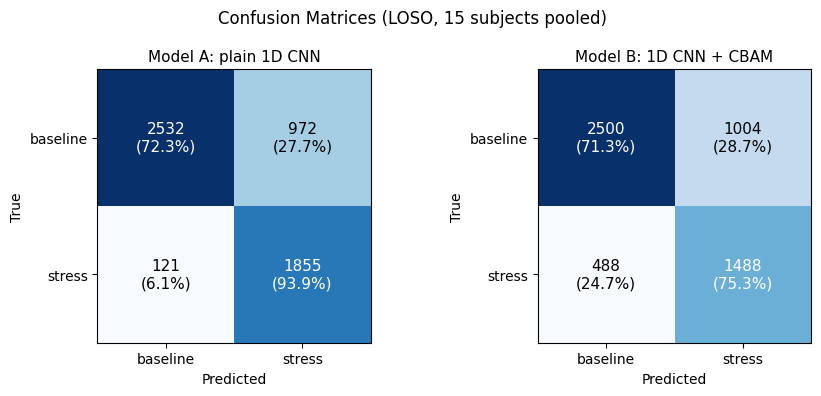

saved -> processed/fig3_confusion.png


In [14]:
# Cell 12 — Figure 3: confusion matrices for Model A and Model B (LOSO pooled)

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

cmA = np.load("processed/cmA.npy")
cmB = np.load("processed/cmB.npy")
classes = ["baseline", "stress"]

def draw_cm(ax, cm, title):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title, fontsize=11)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(classes); ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            # show count + row-normalized % so class sizes are readable
            pct = cm[i, j] / cm[i].sum() * 100
            ax.text(j, i, f"{cm[i, j]}\n({pct:.1f}%)",
                    ha="center", va="center", fontsize=11,
                    color="white" if cm[i, j] > thresh else "black")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
draw_cm(axes[0], cmA, "Model A: plain 1D CNN")
draw_cm(axes[1], cmB, "Model B: 1D CNN + CBAM")
fig.suptitle("Confusion Matrices (LOSO, 15 subjects pooled)", fontsize=12)
fig.tight_layout()
fig.savefig("processed/fig3_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved -> processed/fig3_confusion.png")

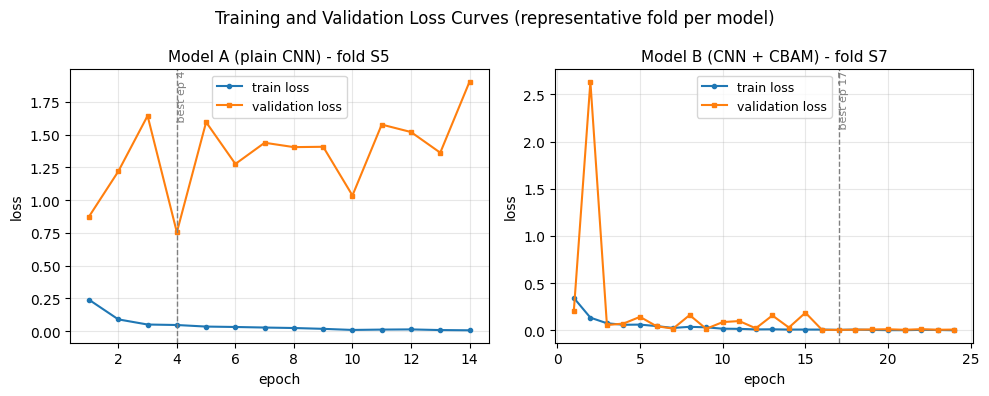

saved -> processed/fig2_curves.png  (A: S5, B: S7)


In [25]:
# Cell 13 (final) - Figure 2: training vs validation LOSS, representative folds (A: S5, B: S7)
import numpy as np
import matplotlib.pyplot as plt

histA = np.load("processed/loso_A_rep_history.npy", allow_pickle=True).item()
histB = np.load("processed/loso_B_rep_history.npy", allow_pickle=True).item()

def plot_loss(ax, hist, title):
    ep = range(1, len(hist["train_loss"]) + 1)
    ax.plot(ep, hist["train_loss"], marker="o", ms=3, label="train loss")
    ax.plot(ep, hist["val_loss"],   marker="s", ms=3, label="validation loss")
    best = int(np.argmin(hist["val_loss"]))
    ax.axvline(best + 1, color="gray", ls="--", lw=1)
    ax.text(best + 1, ax.get_ylim()[1], f" best ep {best+1}",
            color="gray", fontsize=8, rotation=90, va="top")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("epoch"); ax.set_ylabel("loss")
    ax.grid(alpha=0.3); ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_loss(axes[0], histA, "Model A (plain CNN) - fold S5")
plot_loss(axes[1], histB, "Model B (CNN + CBAM) - fold S7")
fig.suptitle("Training and Validation Loss Curves (representative fold per model)", fontsize=12)
fig.tight_layout()
fig.savefig("processed/fig2_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved -> processed/fig2_curves.png  (A: S5, B: S7)")

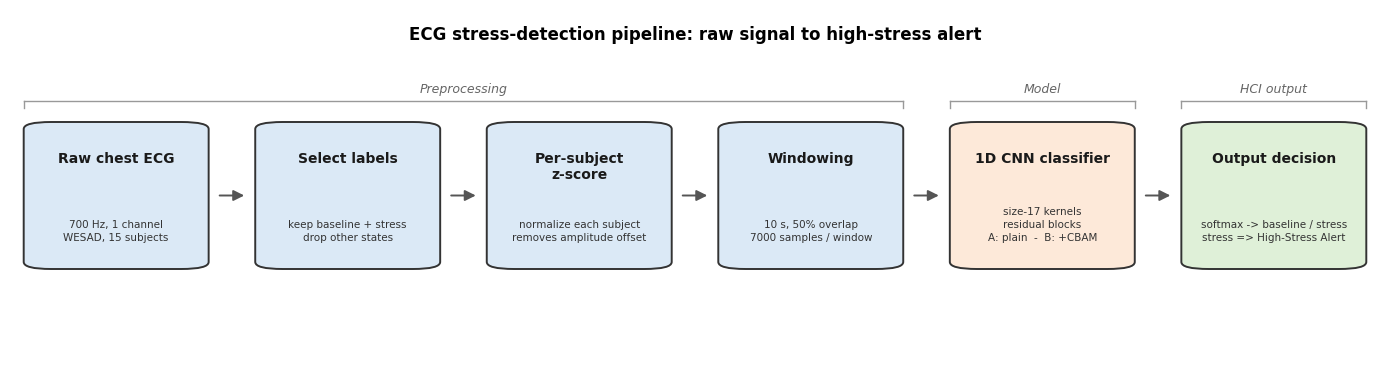

saved -> processed/fig1_pipeline.png


In [17]:
# Cell 14 — Figure 1: system pipeline block diagram (raw ECG -> stress alert)

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# each stage: (title, detail lines, fill color)
stages = [
    ("Raw chest ECG",        "700 Hz, 1 channel\nWESAD, 15 subjects",            "#dbe9f6"),
    ("Select labels",        "keep baseline + stress\ndrop other states",        "#dbe9f6"),
    ("Per-subject\nz-score", "normalize each subject\nremoves amplitude offset", "#dbe9f6"),
    ("Windowing",            "10 s, 50% overlap\n7000 samples / window",         "#dbe9f6"),
    ("1D CNN classifier",    "size-17 kernels\nresidual blocks\nA: plain  -  B: +CBAM", "#fde9d9"),
    ("Output decision",      "softmax -> baseline / stress\nstress => High-Stress Alert", "#dff0d8"),
]

n = len(stages)
fig, ax = plt.subplots(figsize=(14, 3.8))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

# box geometry (axes coords)
w, h = 0.135, 0.42
y0   = 0.26
yc   = y0 + h / 2
left = 0.01
gap  = (0.98 - n * w) / (n - 1)
centers = [left + w / 2 + i * (w + gap) for i in range(n)]

box_kw = dict(boxstyle="round,pad=0,rounding_size=0.02", linewidth=1.4, edgecolor="#333333")

for cx, (title, detail, color) in zip(centers, stages):
    ax.add_patch(FancyBboxPatch((cx - w / 2, y0), w, h, facecolor=color, **box_kw))
    ax.text(cx, y0 + h - 0.085, title, ha="center", va="top",
            fontsize=10, fontweight="bold", color="#1a1a1a", linespacing=1.2)
    ax.text(cx, y0 + 0.075, detail, ha="center", va="bottom",
            fontsize=7.5, color="#333333", linespacing=1.35)

# arrows between consecutive boxes
for i in range(n - 1):
    ax.add_patch(FancyArrowPatch((centers[i] + w / 2 + 0.006, yc),
                                 (centers[i + 1] - w / 2 - 0.006, yc),
                                 arrowstyle="-|>", mutation_scale=16,
                                 linewidth=1.4, color="#555555"))

# group brackets above
def group_label(i0, i1, text):
    xL, xR = centers[i0] - w / 2, centers[i1] + w / 2
    yb = y0 + h + 0.06
    ax.plot([xL, xR], [yb, yb], color="#999999", lw=1.0)
    ax.plot([xL, xL], [yb, yb - 0.02], color="#999999", lw=1.0)
    ax.plot([xR, xR], [yb, yb - 0.02], color="#999999", lw=1.0)
    ax.text((xL + xR) / 2, yb + 0.015, text, ha="center", va="bottom",
            fontsize=9, fontstyle="italic", color="#666666")

group_label(0, 3, "Preprocessing")
group_label(4, 4, "Model")
group_label(5, 5, "HCI output")

ax.text(0.5, 0.93, "ECG stress-detection pipeline: raw signal to high-stress alert",
        ha="center", va="center", fontsize=12, fontweight="bold")

fig.tight_layout()
fig.savefig("processed/fig1_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved -> processed/fig1_pipeline.png")

In [18]:
# Cell 15 — inference latency (per 10 s window), GPU and CPU

import numpy as np, torch, time

# load the trained Model A weights (your recommended system) and measure it
model = ECGNet(n_classes=2, base=32, k=17, p_drop=0.5, attn_factory=None).to(device)
model.load_state_dict(torch.load("processed/model_A.pt", map_location=device))
model.eval()

def measure(m, dev, n_warmup=10, n_runs=100):
    m = m.to(dev); m.eval()
    x = torch.randn(1, 1, WINDOW_SAMPLES, device=dev)   # ONE window, as in deployment
    with torch.no_grad():
        for _ in range(n_warmup):                       # warmup (cuDNN autotune / caches)
            _ = m(x)
        if dev.type == "cuda": torch.cuda.synchronize()
        t = []
        for _ in range(n_runs):
            if dev.type == "cuda": torch.cuda.synchronize()
            s = time.perf_counter()
            _ = m(x)
            if dev.type == "cuda": torch.cuda.synchronize()  # wait for GPU to actually finish
            t.append((time.perf_counter() - s) * 1000.0)     # ms
    return np.array(t)

gpu = measure(model, device) if torch.cuda.is_available() else None
cpu = measure(model, torch.device("cpu"))

if gpu is not None:
    print("GPU  per-window: mean=%.3f ms  median=%.3f ms  p95=%.3f ms" %
          (gpu.mean(), np.median(gpu), np.percentile(gpu, 95)))
print("CPU  per-window: mean=%.3f ms  median=%.3f ms  p95=%.3f ms" %
      (cpu.mean(), np.median(cpu), np.percentile(cpu, 95)))

print("\nfor context: each window covers %d s of ECG; a new window arrives every %.1f s (50%% overlap)."
      % (WINDOW_SEC, WINDOW_SEC * 0.5))

# clean up
try:
    model.to("cpu"); del model
except: pass
gc.collect(); torch.cuda.empty_cache()

C:\Users\abdal\AppData\Local\Temp\ipykernel_37624\4197452595.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("processed/model_A.pt", map

GPU  per-window: mean=3.882 ms  median=3.594 ms  p95=5.805 ms
CPU  per-window: mean=17.119 ms  median=14.239 ms  p95=29.542 ms

for context: each window covers 10 s of ECG; a new window arrives every 5.0 s (50% overlap).


In [19]:
import os
folder = os.path.abspath("processed")
print("Your report figures are here:")
print(folder)
print("\nPNG files in there:")
for f in sorted(os.listdir("processed")):
    if f.endswith(".png"):
        print("   ", f)

os.startfile(folder)   # opens the folder in File Explorer (Windows)

Your report figures are here:
C:\Users\abdal\processed

PNG files in there:
    fig1_pipeline.png
    fig2_curves.png
    fig3_confusion.png
